<a href="https://colab.research.google.com/github/SatyaUdisi/task4/blob/main/real_world_finance_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded. Total Records Evaluated: 200


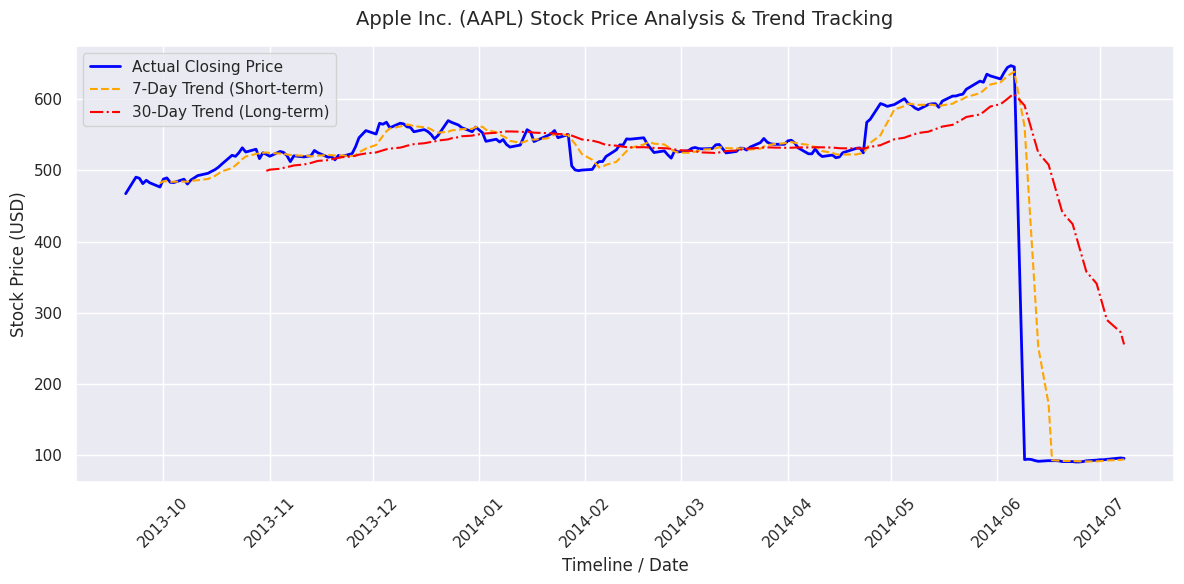

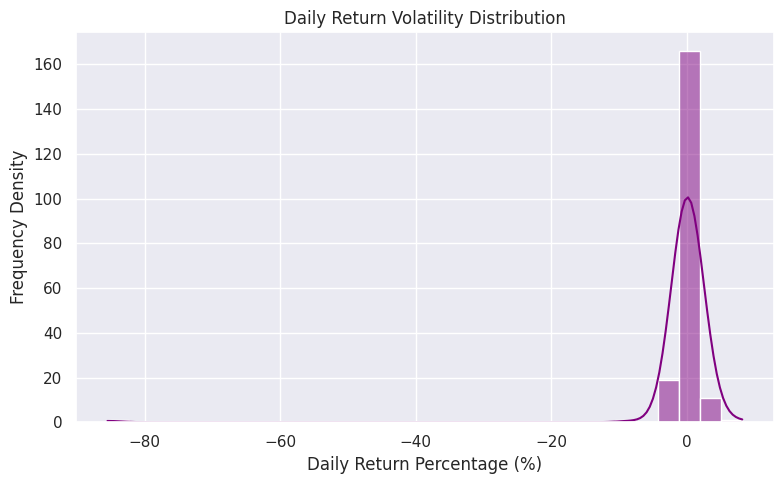

Financial analytics pipeline execution complete!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# ==========================================
# 1. LOAD DOMAIN-SPECIFIC DATA (Finance)
# ==========================================
# Updated, ultra-stable public URL for Apple stock records
url = "https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv"
df = pd.read_csv(url)

# Convert Date column to datetime format and sort
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Filter to look at a specific recent window (e.g., last 200 trading days)
df = df.tail(200).reset_index(drop=True)
print("Dataset Loaded. Total Records Evaluated:", df.shape[0])

# ==========================================
# 2. PREPROCESSING & FEATURE ENGINEERING
# ==========================================
# Check for missing values
df = df.dropna()

# Feature Engineering: Calculate 7-day and 30-day Moving Averages to capture trends
df['7_Day_MA'] = df['Close'].rolling(window=7).mean()
df['30_Day_MA'] = df['Close'].rolling(window=30).mean()

# Calculate Daily Returns percentage (Volatility metric)
df['Daily_Return'] = df['Close'].pct_change() * 100

# ==========================================
# 3. VISUALIZATION & ANALYSIS
# ==========================================
sns.set_theme(style="darkgrid")

# Chart 1: Stock Price Trends with Moving Averages
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Actual Closing Price', color='blue', linewidth=2)
plt.plot(df['Date'], df['7_Day_MA'], label='7-Day Trend (Short-term)', color='orange', linestyle='--')
plt.plot(df['Date'], df['30_Day_MA'], label='30-Day Trend (Long-term)', color='red', linestyle='-.')

plt.title('Apple Inc. (AAPL) Stock Price Analysis & Trend Tracking', fontsize=14, pad=15)
plt.xlabel('Timeline / Date')
plt.ylabel('Stock Price (USD)')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('stock_trend_analysis.png', dpi=300)
plt.show()

# Chart 2: Volatility Distribution (Daily Returns)
plt.figure(figsize=(8, 5))
sns.histplot(df['Daily_Return'].dropna(), kde=True, color='purple', bins=30)
plt.title('Daily Return Volatility Distribution', fontsize=12)
plt.xlabel('Daily Return Percentage (%)')
plt.ylabel('Frequency Density')
plt.tight_layout()
plt.savefig('stock_volatility_distribution.png', dpi=300)
plt.show()

print("Financial analytics pipeline execution complete!")